This is a notebook to produce an example bell curve plot for ensemble bias

In [2]:
from typing import List, Dict, Any, Set

import os
import pandas as pd
from collections import defaultdict

from rdametrics import states, chambers, ensembles

scores_path: str = "~/local/beta-ensembles/prepackaged/scores/scores.parquet"
scores_df = pd.read_parquet(os.path.expanduser(scores_path))

Get `disproportionaility` for the NC/congress R75 ensemble

In [3]:
import numpy as np
from data.helpers import arr_from_scores

xx: str = "NC"
chamber: str = "congress"
ensemble: str = "R75"
# metric: str = "disproportionality"
metric: str = "estimated_seats"

values = arr_from_scores(xx, chamber, ensemble, metric, scores_df)

print(f"{xx}, {chamber}, {ensemble}, {metric}")
print(f"len: {len(values)}")
print(f"mean: {np.mean(values):.2f}")
print(f"median: {float(np.median(values)):.2f}")
print(f"min: {np.min(values):.2f}")
print(f"max: {np.max(values):.2f}")
print(f"std: {np.std(values):.2f}")


NC, congress, R75, estimated_seats
len: 20000
mean: 6.19
median: 6.19
min: 4.57
max: 7.58
std: 0.40


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = values * 100

plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

mean_value = data.mean()
plt.axvline(0, color='green', linestyle='-', linewidth=2, label='Unbiased = 0%')
plt.axvline(mean_value, color='black', linestyle='-', linewidth=2, label=f'Mean = {mean_value:.2f}%')
# median_value = float(np.median(data))
# plt.axvline(median_value, color='purple', linestyle=':', linewidth=2, label=f'Median = {median_value:.2f}%')
plt.axvline(1.19, color='blue', linestyle='--', linewidth=2, label='NC 2022 = 1.19%') # NC 2022
plt.axvline(20.03, color='red', linestyle='--', linewidth=2, label='NC 2024 = 20.03%') # NC 2024

plt.xlabel('Disproportionality (%)')
plt.ylabel('Probability Density')
plt.title('NC/Congress R75 Ensemble')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

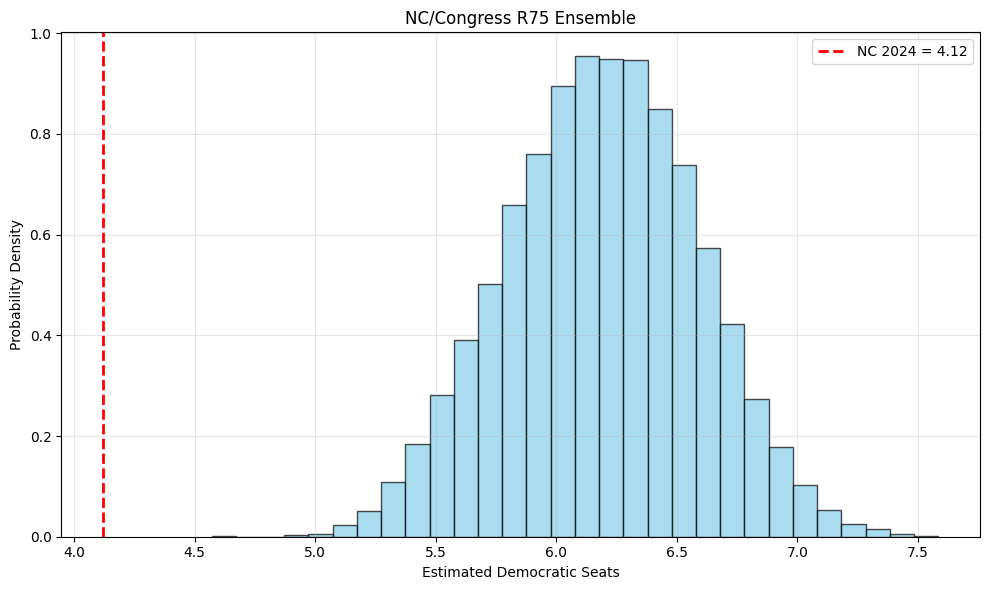

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = values

plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

mean_value = data.mean()
# plt.axvline(0, color='green', linestyle='-', linewidth=2, label='Unbiased = 0%')
# plt.axvline(mean_value, color='black', linestyle='-', linewidth=2, label=f'Mean = {mean_value:.2f}%')
# median_value = float(np.median(data))
# plt.axvline(median_value, color='purple', linestyle=':', linewidth=2, label=f'Median = {median_value:.2f}%')
# plt.axvline(1.19, color='blue', linestyle='--', linewidth=2, label='NC 2022 = 1.19%') # NC 2022
plt.axvline(4.12, color='red', linestyle='--', linewidth=2, label='NC 2024 = 4.12') # NC 2024

plt.xlabel('Estimated Democratic Seats')
plt.ylabel('Probability Density')
plt.title('NC/Congress R75 Ensemble')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()